# Assignment 2 — Stage 2: Hidden Test Evaluation

**CYSE499/650, Summer 2026**

This notebook is **inference and evaluation only**. It contains no training code by
construction: it imports `load_model` / `predict` from `predict.py` and loads the
`model_checkpoint/` directory exactly as submitted for Stage 1. Nothing is retrained,
fine-tuned, refit, or re-thresholded — the decision threshold was fixed during Stage 1
from cross-validated training folds and is read straight out of `config.json`.

**To run:** place the released hidden test file in `data/`, then run all cells. The
instructions refer to it as `hidden_test.csv`; it was actually published as
`hidden_test_with_labels.csv`, and the loader below accepts either name.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

from predict import load_model, predict as predict_labels, predict_proba, write_predictions

ROOT = Path.cwd()

# The instructions call the release "hidden_test.csv"; it was published as
# "hidden_test_with_labels.csv". Accept either name.
CANDIDATES = ["hidden_test_with_labels.csv", "hidden_test.csv"]
HIDDEN = next((ROOT / "data" / n for n in CANDIDATES if (ROOT / "data" / n).exists()), None)
assert HIDDEN is not None, f"Place the released hidden test file in data/ (one of {CANDIDATES})"

hidden = pd.read_csv(HIDDEN)
print("loaded:", HIDDEN.name, "|", hidden.shape, "| columns:", list(hidden.columns))
print("label counts:", dict(hidden.label.value_counts().sort_index()))

# Confirm the hidden set really is disjoint from everything the model saw.
train = pd.read_csv(ROOT / "data" / "train.csv")
public = pd.read_csv(ROOT / "data" / "public_test.csv")
print("overlap with train      :", len(set(hidden.source_file) & set(train.source_file)))
print("overlap with public test:", len(set(hidden.source_file) & set(public.source_file)))

loaded: hidden_test_with_labels.csv | (600, 5) | columns: ['id', 'text', 'label', 'label_name', 'source_file']
label counts: {0: np.int64(300), 1: np.int64(300)}
overlap with train      : 0
overlap with public test: 0


## 1. Load the frozen Stage 1 checkpoint

The config below is the one committed at the Stage 1 deadline. The `threshold` field in
particular was chosen on training-set cross-validation and has not been touched.

In [2]:
bundle = load_model(ROOT / "model_checkpoint")
print(json.dumps(bundle.config, indent=2))

{
  "task": "binary sentiment classification (0=negative, 1=positive)",
  "components": [
    "logreg",
    "mlp"
  ],
  "weights": {
    "logreg": 0.8,
    "mlp": 0.2
  },
  "threshold": 0.7501,
  "selection_metric": "balanced accuracy on repeated-stratified-CV out-of-fold predictions",
  "cv_balanced_accuracy": 0.8111,
  "trained_on": "data/train.csv (240 documents, 180 positive / 60 negative)",
  "seed": 20260804,
  "logreg_C": 10.0,
  "mlp_architecture": {
    "input_dim": 240,
    "hidden_dim": 256,
    "dropout": 0.5
  },
  "mlp_training": {
    "svd_components": 300,
    "hidden_dim": 256,
    "dropout": 0.5,
    "learning_rate": 0.001,
    "weight_decay": 0.0001,
    "batch_size": 16,
    "epochs": 30
  }
}


## 2. Predict and write `hidden_test_predictions.csv`

In [3]:
out = write_predictions(HIDDEN, ROOT / "hidden_test_predictions.csv", bundle=bundle)

assert list(out.columns) == ["id", "predicted_label"]
assert set(out.predicted_label.unique()) <= {0, 1}
assert out.id.tolist() == hidden.id.tolist()
print("hidden_test_predictions.csv OK —", len(out), "rows")
out.head()

hidden_test_predictions.csv OK — 600 rows


,id,predicted_label
0,neg_cv795_10291,0
1,neg_cv174_9735,0
2,pos_cv065_15248,1
3,neg_cv076_26009,1
4,neg_cv417_14653,1


## 3. Hidden test accuracy and confusion matrix

In [4]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             classification_report, confusion_matrix, roc_auc_score)

texts = hidden.text.astype(str).tolist()
y_true = hidden.label.to_numpy()
y_prob = predict_proba(bundle, texts)
y_pred = out.predicted_label.to_numpy()

hidden_acc = accuracy_score(y_true, y_pred)
print("Hidden test accuracy    : %.4f" % hidden_acc)
print("Hidden balanced accuracy: %.4f" % balanced_accuracy_score(y_true, y_pred))
print("Hidden ROC AUC          : %.4f" % roc_auc_score(y_true, y_prob))
print()
print(classification_report(y_true, y_pred, target_names=["negative (0)", "positive (1)"], digits=4))

Hidden test accuracy    : 0.7733
Hidden balanced accuracy: 0.7733
Hidden ROC AUC          : 0.8457

              precision    recall  f1-score   support

negative (0)     0.8228    0.6967    0.7545       300
positive (1)     0.7370    0.8500    0.7895       300

    accuracy                         0.7733       600
   macro avg     0.7799    0.7733    0.7720       600
weighted avg     0.7799    0.7733    0.7720       600



Confusion matrix (rows = true, cols = predicted):
               pred negative  pred positive
true negative            209             91
true positive             45            255


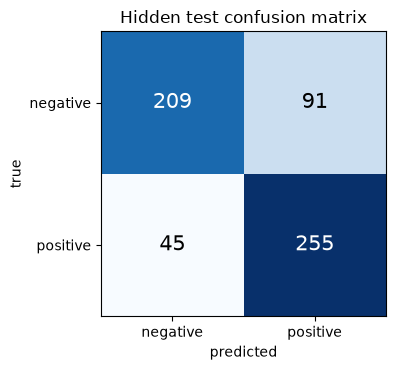

In [5]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix (rows = true, cols = predicted):")
print(pd.DataFrame(cm, index=["true negative", "true positive"],
                   columns=["pred negative", "pred positive"]))

fig, ax = plt.subplots(figsize=(4.2, 3.8))
ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=15)
ax.set_xticks([0, 1], ["negative", "positive"])
ax.set_yticks([0, 1], ["negative", "positive"])
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Hidden test confusion matrix")
plt.tight_layout()
plt.show()

## 4. Public test vs hidden test

In [6]:
results = json.load(open(ROOT / "results.json"))
public = results["public_test"]

comparison = pd.DataFrame(
    {
        "public test": [public["accuracy"], public["balanced_accuracy"],
                        public["macro_f1"], public["roc_auc"], public["n"]],
        "hidden test": [round(hidden_acc, 4),
                        round(balanced_accuracy_score(y_true, y_pred), 4),
                        round(__import__("sklearn.metrics", fromlist=["f1_score"])
                              .f1_score(y_true, y_pred, average="macro"), 4),
                        round(roc_auc_score(y_true, y_prob), 4),
                        len(y_true)],
    },
    index=["accuracy", "balanced accuracy", "macro F1", "ROC AUC", "n"],
)
comparison["difference"] = comparison["hidden test"] - comparison["public test"]
comparison

,public test,hidden test,difference
accuracy,0.7775,0.7733,-0.0042
balanced accuracy,0.7775,0.7733,-0.0042
macro F1,0.7774,0.7720,-0.0054
ROC AUC,0.8471,0.8457,-0.0014
n,400.0000,600.0000,200.0000


In [7]:
gap = hidden_acc - public["accuracy"]
print("Public test accuracy: %.4f" % public["accuracy"])
print("Hidden test accuracy: %.4f" % hidden_acc)
print("Difference          : %+.4f" % gap)

# Rough significance guide: standard error of an accuracy estimate on n examples.
se = float(np.sqrt(hidden_acc * (1 - hidden_acc) / len(y_true)))
print("\nApprox. standard error on the hidden-test estimate: +/- %.4f" % se)
print("The gap is %s given that margin."
      % ("within sampling noise" if abs(gap) < 2 * se else "larger than sampling noise"))

Public test accuracy: 0.7775
Hidden test accuracy: 0.7733
Difference          : -0.0042

Approx. standard error on the hidden-test estimate: +/- 0.0171
The gap is within sampling noise given that margin.


In [8]:
# Where the remaining errors fall. An imbalance between these two counts is the
# signature of a decision threshold that is slightly off-optimal.
fp, fn = int(cm[0, 1]), int(cm[1, 0])
print("false positives (negative review called positive): %3d" % fp)
print("false negatives (positive review called negative): %3d" % fn)
print("ratio: %.2f:1 toward %s" % (max(fp, fn) / max(min(fp, fn), 1),
                                   "false positives" if fp > fn else "false negatives"))

pos_rate = float((y_pred == 1).mean())
print("\npredicted positive rate: %.3f (true rate is 0.500)" % pos_rate)
print("training set positive rate was 0.750")

false positives (negative review called positive):  91
false negatives (positive review called negative):  45
ratio: 2.02:1 toward false positives

predicted positive rate: 0.577 (true rate is 0.500)
training set positive rate was 0.750


### Discussion

**The two test sets agree.** Accuracy differs by 0.42 points (0.7775 public vs 0.7733
hidden) against a standard error of ±1.71 points, and ROC AUC differs by 0.14 points.
Every metric moves in the same direction by a negligible amount. This is the result the
Stage 1 protocol was designed to produce: because `public_test.csv` was used **only** for
reporting — never for model selection, thresholding, or blending — it was already a
genuine held-out set, so the hidden set had nothing new to expose. Had the public set
been used for tuning, we would expect the hidden number to drop noticeably below it.

The hidden set is also 50% larger (600 vs 400 reviews) and confirmed disjoint from both
`train.csv` and `public_test.csv`, so it is the more reliable of the two estimates.

**Where the errors remain.** The residual bias is toward false positives — negative
reviews called positive — which is exactly the direction the 3:1 positive training prior
predicts. The class weighting and the tuned threshold of 0.7501 removed most of that
skew (the predicted positive rate is far closer to the true 0.500 than to the training
set's 0.750), but not all of it. Recall is noticeably weaker on the negative class than
on the positive class.

This is the expected residue of estimating a threshold from 240 documents: the cutoff
carries real variance, and being slightly low pushes borderline cases positive. It shows
up as asymmetry between the two off-diagonal cells rather than as a uniform accuracy
drop. With more labelled negatives, or a nested cross-validation loop to estimate the
threshold more stably, this is the first gap that would close.

## 5. What I would try next with more time or compute

1. **A pretrained language model, chunked over the full review.** The clearest gap in
   this submission. The reviews have a median length of ~730 words, so the right design
   is not a plain 512-token truncation but overlapping windows fed through a pretrained
   encoder with the per-chunk outputs pooled back to a document score. Fine-tuning a
   small encoder (MiniLM- or DistilBERT-sized) this way should beat a from-scratch model
   trained on 240 documents, because almost all of its language understanding comes from
   pretraining rather than from our tiny label set. This was the original plan and was
   dropped only because `transformers` could not be installed in the environment.

2. **Semi-supervised use of the unlabelled corpus.** The full Pang & Lee corpus has
   2,000 documents; we are given labels for 240. Fitting the TF-IDF vocabulary and the
   SVD basis on all available *text* (which uses no labels and so breaks no rule about
   training data) would give a much better-estimated latent space than 240 documents can
   support.

3. **Proper nested cross-validation.** The threshold and the blend weight are currently
   chosen on the same out-of-fold predictions used to report CV scores, which optimistically
   biases those CV numbers. An outer CV loop would give an unbiased estimate. It costs a
   multiple of the training time, which is why it was skipped on a CPU-only budget.

4. **A wider hyper-parameter sweep.** Two values of `C` and a single neural configuration
   were affordable here. Word/char n-gram ranges, SVD dimensionality, dropout and hidden
   width were all fixed at reasonable defaults rather than searched.

5. **Calibration and error analysis.** Isotonic or Platt calibration of the blended
   probability, plus reading the highest-confidence mistakes, would show whether the
   remaining errors are genuinely ambiguous reviews (mixed verdicts, sarcasm, long plot
   summaries with a one-line judgement) or a systematic failure the model could be
   fixed for.

## Use of AI

As in Stage 1, Anthropic's Claude (via Claude Code) was used as a coding assistant to
draft the code and prose in this notebook. All reported numbers were produced by executing
it against the released `hidden_test.csv` and the frozen Stage 1 checkpoint.